In [1]:
import datasets as hfds
from matplotlib import pyplot as plt
import numpy as np

In [2]:
plt.rcParams["figure.dpi"] = 150

In [4]:
dataset_dict = hfds.load_from_disk("../datasets/nsd_flat_cococlip")
dataset_dict.set_format("numpy")

In [5]:
samples = [dataset_dict["train"][ii] for ii in range(64)]
images = np.stack([sample["activity"].squeeze() for sample in samples])
mask = ~(images == 127).all(axis=0)
images = images / 255

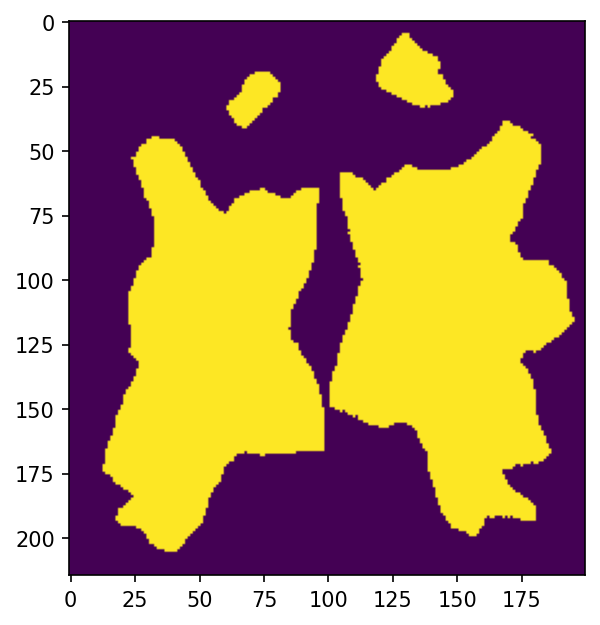

In [6]:
plt.imshow(mask)

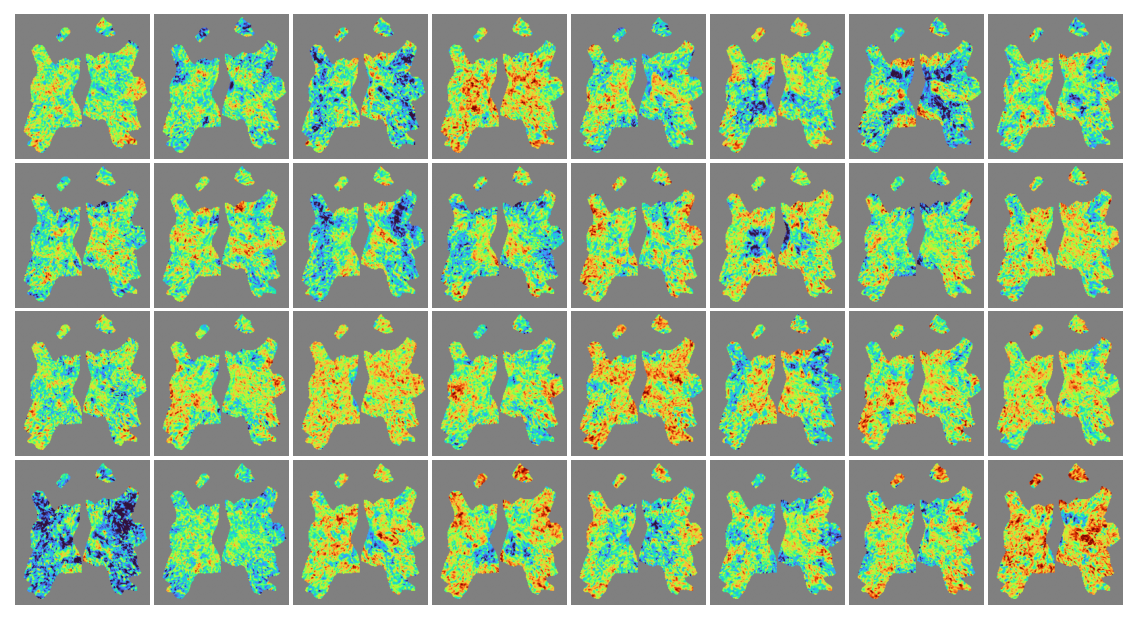

In [13]:
H, W = mask.shape
ploth = 1.0
plotw = (W / H) * ploth
nr = 4
nc = 8
f, axs = plt.subplots(nr, nc, figsize=(nc * plotw, nr * ploth))
axs = axs.flatten()

cmap = plt.get_cmap("turbo")
cmap.set_bad("gray")

for ii, ax in enumerate(axs):
    plt.sca(ax)
    plt.imshow(np.where(mask, images[ii], np.nan), cmap=cmap, vmin=0, vmax=1)
    plt.axis("off")

plt.tight_layout(pad=0.2)

In [12]:
np.save("../metadata/nsd_flat_mask.npy", mask)